                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     4.967
Date:                Fri, 08 May 2026   Prob (F-statistic):           0.000160
Time:                        13:20:44   Log-Likelihood:                -233.49
No. Observations:                  45   AIC:                             491.0
Df Residuals:                      33   BIC:                             512.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

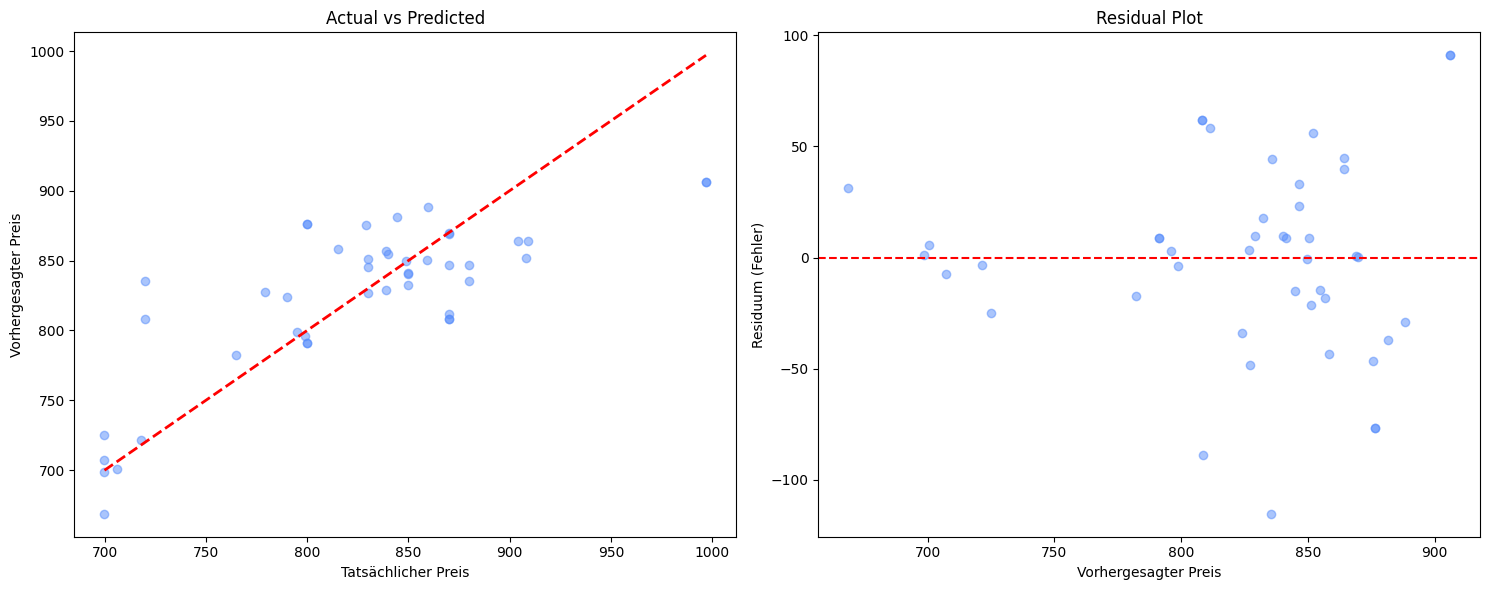

In [2]:
# Ist es noch 45? Aktuell sind mehr Daten schon vorhanden, bestimmt??
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from color_mapping import clean_color_column
from country_mapping import clean_country_column

# 1. Daten laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)


# 2. Bereinigungs-Funktionen
def clean_price(value):
    if pd.isna(value):
        return np.nan
    v = (
        str(value)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(v)
    except:
        return np.nan


def clean_numeric(value):
    if pd.isna(value):
        return np.nan
    v = (
        str(value)
        .replace("%", "")
        .replace("+", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    if v == "N/A":
        return np.nan
    try:
        return float(v)
    except:
        return np.nan


# 3. Features extrahieren und bereinigen
model_df = df.copy()
model_df["price"] = model_df["Preis"].apply(clean_price)
model_df["seller_rating"] = model_df["Seller Rating"].apply(clean_numeric)
model_df["available_stock"] = model_df["Verfugbar"].apply(clean_numeric)
model_df["number_sold"] = model_df["verkauft"].apply(clean_numeric)

# Relevante Spalten auswählen
cols_to_keep = [
    "price",
    "Zustand",
    "Farbe",
    "seller_rating",
    "Seller Type",
    "available_stock",
    "number_sold",
    "Herkunftsland",
]
regression_df = model_df[cols_to_keep].dropna()

# 3.5 farben sorter und bereinigen
regression_df["Farbe"] = clean_color_column(regression_df["Farbe"])
regression_df["Herkunftsland"] = clean_country_column(regression_df["Herkunftsland"])

# 4. Encoding (WICHTIG: dtype=float verhindert Boolean-Fehler)
regression_encoded = pd.get_dummies(
    regression_df,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
    dtype=float,
)

# 5. Regression vorbereiten
X = regression_encoded.drop("price", axis=1)
y = regression_encoded["price"]

# Konstante hinzufügen (Intercept)
X = sm.add_constant(X)

# 6. Modell berechnen
model = sm.OLS(y, X).fit()
print(model.summary())

# 7. Ergebnistabelle erstellen
results_table = pd.DataFrame(
    {
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "P-value": model.pvalues.values,
    }
).sort_values("P-value")

# In Jupyter/Colab: display(results_table), sonst print:
print("\n--- Zusammenfassung der Variablen ---")
print(results_table)

# 8. Visualisierung
regression_encoded["predicted_price"] = model.predict(X)
regression_encoded["residual"] = (
    regression_encoded["price"] - regression_encoded["predicted_price"]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Ist vs. Soll
ax1.scatter(
    regression_encoded["price"], regression_encoded["predicted_price"], alpha=0.5
)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
ax1.set_xlabel("Tatsächlicher Preis")
ax1.set_ylabel("Vorhergesagter Preis")
ax1.set_title("Actual vs Predicted")

# Plot 2: Residuen
ax2.scatter(
    regression_encoded["predicted_price"], regression_encoded["residual"], alpha=0.5
)
ax2.axhline(0, color="red", linestyle="--")
ax2.set_xlabel("Vorhergesagter Preis")
ax2.set_ylabel("Residuum (Fehler)")
ax2.set_title("Residual Plot")

plt.tight_layout()
plt.show()


# Tambahan ya
regression_df["seller_rating"] = regression_df["seller_rating"].fillna(
    regression_df["seller_rating"].mean()
)